In [9]:
# reading crop classes chips
import os
import glob
import rioxarray as rio
import rasterio
from rasterio.merge import merge
import xarray as xr
import numpy as np



file_id = 50

train_dir = '/discover/nobackup/ejalilva/data/prithvi/datasets--ibm-nasa-geospatial--multi-temporal-crop-classification/snapshots/04b439f179e52a7b144f69676210eecd30c39cfc/training_chips/'
val_dir = '/discover/nobackup/ejalilva/data/prithvi/datasets--ibm-nasa-geospatial--multi-temporal-crop-classification/snapshots/04b439f179e52a7b144f69676210eecd30c39cfc/validation_chips/'
cdl20_path = '/discover/nobackup/ejalilva/data/irrigation_FM/2020_30m_cdls.tif'
lgrip_tiles_dir = '/discover/nobackup/ejalilva/data/irrigation_FM'
# files = glob.glob(os.path.join(train_dir,'*mask.tif'))
# print(len(files))

In [10]:
original_chip = rio.open_rasterio(files[file_id])
chip_crs = str(original_chip.rio.crs)
chip = original_chip.sel(band=1).drop_vars('band')
chip.x

<xarray.DataArray 'x' (x: 224)> Size: 2kB
array([-750000., -749970., -749940., ..., -743370., -743340., -743310.])
Coordinates:
  * x            (x) float64 2kB -7.5e+05 -7.5e+05 ... -7.433e+05 -7.433e+05
    spatial_ref  int64 8B 0

In [11]:
# Complete CDL irrigation likelihood map with official colors
# Format: CDL_code: (irrigation_likelihood, hex_color, crop_name)

CDL_IRRIGATION_MAP = {
    # NO DATA (0)
    0: (0, '#000000', 'Background'),
    81: (0, '#f7f7f7', 'Clouds/No Data'),
    
    # HIGHLY LIKELY IRRIGATED (1) - Nearly always irrigated
    3: (1, '#00a9e6', 'Rice'),
    14: (1, '#80d4ff', 'Mint'),
    41: (1, '#a900e6', 'Sugarbeets'),
    47: (1, '#ff6666', 'Misc Vegs & Fruits'),
    48: (1, '#ff6666', 'Watermelons'),
    49: (1, '#ffcc66', 'Onions'),
    50: (1, '#ff6666', 'Cucumbers'),
    51: (1, '#00af4d', 'Chick Peas'),
    52: (1, '#00deb0', 'Lentils'),
    53: (1, '#55ff00', 'Peas'),
    54: (1, '#f5a27a', 'Tomatoes'),
    55: (1, '#ff6666', 'Caneberries'),
    56: (1, '#00af4d', 'Hops'),
    57: (1, '#80d4ff', 'Herbs'),
    66: (1, '#ff00ff', 'Cherries'),
    67: (1, '#ff91ab', 'Peaches'),
    68: (1, '#b90050', 'Apples'),
    69: (1, '#704489', 'Grapes'),
    70: (1, '#007878', 'Christmas Trees'),
    71: (1, '#b39c70', 'Other Tree Crops'),
    72: (1, '#ffff80', 'Citrus'),
    74: (1, '#b6705c', 'Pecans'),
    75: (1, '#00a884', 'Almonds'),
    76: (1, '#ebd6b0', 'Walnuts'),
    77: (1, '#b39c70', 'Pears'),
    92: (1, '#00ffff', 'Aquaculture'),
    204: (1, '#00ff8c', 'Pistachios'),
    206: (1, '#ff6666', 'Carrots'),
    207: (1, '#ff6666', 'Asparagus'),
    208: (1, '#ff6666', 'Garlic'),
    209: (1, '#ff6666', 'Cantaloupes'),
    210: (1, '#ff91ab', 'Prunes'),
    211: (1, '#344a34', 'Olives'),
    212: (1, '#e67525', 'Oranges'),
    213: (1, '#ff6666', 'Honeydew Melons'),
    214: (1, '#ff6666', 'Broccoli'),
    215: (1, '#66994d', 'Avocados'),
    216: (1, '#ff6666', 'Peppers'),
    217: (1, '#b39c70', 'Pomegranates'),
    218: (1, '#ff91ab', 'Nectarines'),
    219: (1, '#ff6666', 'Greens'),
    220: (1, '#ff91ab', 'Plums'),
    221: (1, '#ff6666', 'Strawberries'),
    222: (1, '#ff6666', 'Squash'),
    223: (1, '#ff91ab', 'Apricots'),
    227: (1, '#ff6666', 'Lettuce'),
    229: (1, '#ff6666', 'Pumpkins'),
    242: (1, '#000099', 'Blueberries'),
    243: (1, '#ff6666', 'Cabbage'),
    244: (1, '#ff6666', 'Cauliflower'),
    245: (1, '#ff6666', 'Celery'),
    246: (1, '#ff6666', 'Radishes'),
    247: (1, '#ff6666', 'Turnips'),
    248: (1, '#ff6666', 'Eggplants'),
    249: (1, '#ff6666', 'Gourds'),
    250: (1, '#ff6666', 'Cranberries'),
    
    # LIKELY IRRIGATED (2) - Regional/high-value crops
    1: (2, '#ffd400', 'Corn'),
    2: (2, '#ff2626', 'Cotton'),
    6: (2, '#ffff00', 'Sunflower'),
    11: (2, '#00af4d', 'Tobacco'),
    12: (2, '#e0a60f', 'Sweet Corn'),
    13: (2, '#e0a60f', 'Pop or Orn Corn'),
    36: (2, '#ffa8e3', 'Alfalfa'),
    43: (2, '#732600', 'Potatoes'),
    45: (2, '#b380ff', 'Sugarcane'),
    46: (2, '#732600', 'Sweet Potatoes'),
    60: (2, '#00af4d', 'Switchgrass'),
    # Double crop (usually requires irrigation)
    26: (2, '#737300', 'Dbl Crop WinWht/Soybeans'),
    225: (2, '#ffd400', 'Dbl Crop WinWht/Corn'),
    226: (2, '#ffd400', 'Dbl Crop Oats/Corn'),
    228: (2, '#ffd400', 'Dbl Crop Triticale/Corn'),
    230: (2, '#8a6453', 'Dbl Crop Lettuce/Durum Wht'),
    231: (2, '#ff6666', 'Dbl Crop Lettuce/Cantaloupe'),
    232: (2, '#ff2626', 'Dbl Crop Lettuce/Cotton'),
    233: (2, '#e2007f', 'Dbl Crop Lettuce/Barley'),
    234: (2, '#ff9e0f', 'Dbl Crop Durum Wht/Sorghum'),
    235: (2, '#ff9e0f', 'Dbl Crop Barley/Sorghum'),
    236: (2, '#a87000', 'Dbl Crop WinWht/Sorghum'),
    237: (2, '#ffd400', 'Dbl Crop Barley/Corn'),
    238: (2, '#a87000', 'Dbl Crop WinWht/Cotton'),
    239: (2, '#267300', 'Dbl Crop Soybeans/Cotton'),
    240: (2, '#267300', 'Dbl Crop Soybeans/Oats'),
    241: (2, '#ffd400', 'Dbl Crop Corn/Soybeans'),
    254: (2, '#267300', 'Dbl Crop Barley/Soybeans'),
    
    # POSSIBLY IRRIGATED (3) - Supplemental irrigation
    4: (3, '#ff9e0f', 'Sorghum'),
    10: (3, '#70a800', 'Peanuts'),
    37: (3, '#a5f58d', 'Other Hay/Non Alfalfa'),
    42: (3, '#a80000', 'Dry Beans'),
    62: (3, '#e9ffbe', 'Pasture/Grass'),
    
    # UNLIKELY IRRIGATED (4) - Typically rainfed
    5: (4, '#267300', 'Soybeans'),
    21: (4, '#e2007f', 'Barley'),
    22: (4, '#8a6453', 'Durum Wheat'),
    23: (4, '#d9b56c', 'Spring Wheat'),
    24: (4, '#a87000', 'Winter Wheat'),
    25: (4, '#d69dbc', 'Other Small Grains'),
    27: (4, '#ae017e', 'Rye'),
    28: (4, '#a15889', 'Oats'),
    29: (4, '#73004c', 'Millet'),
    30: (4, '#d69dbc', 'Speltz'),
    31: (4, '#d1ff00', 'Canola'),
    32: (4, '#8099ff', 'Flaxseed'),
    33: (4, '#d6d600', 'Safflower'),
    34: (4, '#d1ff00', 'Rape Seed'),
    35: (4, '#00af4d', 'Mustard'),
    38: (4, '#00af4d', 'Camelina'),
    39: (4, '#d69dbc', 'Buckwheat'),
    44: (4, '#00af4d', 'Other Crops'),
    58: (4, '#e8beff', 'Clover/Wildflowers'),
    59: (4, '#b2ffde', 'Sod/Grass Seed'),
    61: (4, '#bfbf7a', 'Fallow/Idle Cropland'),
    176: (4, '#e9ffbe', 'Grassland/Pasture'),
    205: (4, '#d69dbc', 'Triticale'),
    224: (4, '#00af4d', 'Vetch'),
    
    # NON-AGRICULTURAL (5)
    63: (5, '#95ce93', 'Forest'),
    64: (5, '#c7d79e', 'Shrubland'),
    65: (5, '#ccbfa3', 'Barren'),
    82: (5, '#9c9c9c', 'Developed'),
    83: (5, '#4d70a3', 'Water'),
    88: (5, '#e9ffbe', 'Nonag/Undefined'),
    111: (5, '#4d70a3', 'Open Water'),
    112: (5, '#d4e3fc', 'Perennial Ice/Snow'),
    121: (5, '#9c9c9c', 'Developed/Open Space'),
    122: (5, '#9c9c9c', 'Developed/Low Intensity'),
    123: (5, '#9c9c9c', 'Developed/Med Intensity'),
    124: (5, '#9c9c9c', 'Developed/High Intensity'),
    131: (5, '#ccbfa3', 'Barren'),
    141: (5, '#95ce93', 'Deciduous Forest'),
    142: (5, '#95ce93', 'Evergreen Forest'),
    143: (5, '#95ce93', 'Mixed Forest'),
    152: (5, '#c7d79e', 'Shrubland'),
    
    # Water (5)
    83: (6, '#4d70a3', 'Water'),
    111: (6, '#4d70a3', 'Open Water'),
    87: (6, '#80b3b3', 'Wetlands'),
    190: (6, '#80b3b3', 'Woody Wetlands'),
    195: (6, '#80b3b3', 'Herbaceous Wetlands')
}

# Extract lookup dictionaries
irrigation_likelihood_map = {k: v[0] for k, v in CDL_IRRIGATION_MAP.items()}
cdl_color_map = {k: v[1] for k, v in CDL_IRRIGATION_MAP.items()}
cdl_name_map = {k: v[2] for k, v in CDL_IRRIGATION_MAP.items()}



In [15]:
# Cell 2: Process chips with location-based adjustments
train_val = 'val' # 'val', 'train'
if train_val == 'train':
    chip_files = glob.glob(f"{train_dir}/*mask.tif")
    output_dir = f'{lgrip_tiles_dir}/cdl_likelihood_mask/ir_likelihood_training'
    os.makedirs(output_dir, exist_ok=True)
else:
    chip_files = glob.glob(f"{val_dir}/*mask.tif")
    output_dir = f'{lgrip_tiles_dir}/cdl_likelihood_mask/ir_likelihood_validation'
    os.makedirs(output_dir, exist_ok=True)

# output_dir = f'{lgrip_tiles_dir}/cdl_likelihood_mask'
cdl_src = rasterio.open(cdl20_path)

print(f"Processing {len(chip_files)} chips...")

# Transform regional boundaries to CDL coordinate system
from rasterio.warp import transform_bounds

# Western US boundary (longitude < -100) to CDL coordinates
western_bounds = transform_bounds('EPSG:4326', cdl_src.crs, -180, 25, -100, 50)
western_x_max = western_bounds[2]

# High Plains boundary (-104 to -96 lon, 36 to 42 lat) to CDL coordinates  
plains_bounds = transform_bounds('EPSG:4326', cdl_src.crs, -104, 36, -96, 42)
plains_x_min, plains_y_min, plains_x_max, plains_y_max = plains_bounds

# California Central Valley (-122 to -119 lon, 35 to 40 lat) to CDL coordinates
ca_bounds = transform_bounds('EPSG:4326', cdl_src.crs, -122, 35, -119, 40)
ca_x_min, ca_y_min, ca_x_max, ca_y_max = ca_bounds

# Midwest Corn Belt (-98 to -80 lon, 38 to 46 lat) to CDL coordinates
midwest_bounds = transform_bounds('EPSG:4326', cdl_src.crs, -98, 38, -80, 46)
midwest_x_min, midwest_y_min, midwest_x_max, midwest_y_max = midwest_bounds
        
for i, chip_file in enumerate(chip_files):
    with rasterio.open(chip_file) as chip:
        # Get chip location (center coordinates) - keep in CDL coordinate system
        bounds = chip.bounds
        center_x = (bounds.left + bounds.right) / 2
        center_y = (bounds.bottom + bounds.top) / 2
        
        # Extract from CDL at same location
        window = rasterio.windows.from_bounds(*chip.bounds, cdl_src.transform)
        cdl_data = cdl_src.read(1, window=window)
        
        # Create irrigation likelihood array
        irrigation_likelihood = np.full_like(cdl_data, 3, dtype=np.uint8)  # Default: possibly irrigated
        # Apply crop-based classification
        for cdl_code, likelihood in irrigation_likelihood_map.items():
            irrigation_likelihood[cdl_data == cdl_code] = likelihood

        # Flag unmapped codes
        unmapped_mask = ~np.isin(cdl_data, list(irrigation_likelihood_map.keys()))
        if unmapped_mask.any():
            unique_unmapped = np.unique(cdl_data[unmapped_mask])
            print(f"Chip {i}: unmapped CDL codes {unique_unmapped}")
        
        # Location-based adjustments using CDL coordinate system
        # Western US (more irrigation)
        if center_x < western_x_max:  # West of 100th meridian in CDL coordinates
            # Upgrade corn and cotton to highly likely irrigated in western US
            corn_mask = (cdl_data == 1) | (cdl_data == 12)  # Corn types
            cotton_mask = cdl_data == 2  # Cotton
            irrigation_likelihood[corn_mask] = 1  # Highly likely
            irrigation_likelihood[cotton_mask] = 1  # Highly likely
            
            # Upgrade other crops that are regionally likely
            regional_crops = [4, 24, 5]  # Sorghum, winter wheat, soybeans
            for crop_code in regional_crops:
                crop_mask = cdl_data == crop_code
                current_class = irrigation_likelihood[crop_mask]
                # Upgrade by one class (but don't exceed highly likely)
                irrigation_likelihood[crop_mask] = np.clip(current_class - 1, 1, 5)
        
        # High Plains (heavy irrigation region)
        if (plains_x_min < center_x < plains_x_max and 
            plains_y_min < center_y < plains_y_max):  # High Plains in CDL coordinates
            # Most crops become likely or highly likely irrigated
            crop_mask = (cdl_data >= 1) & (cdl_data <= 60) & (irrigation_likelihood != 6)  # All crop codes
            current_class = irrigation_likelihood[crop_mask]
            irrigation_likelihood[crop_mask] = np.clip(current_class - 1, 1, 5)

        # California Central Valley (almost everything irrigated)
        if (ca_x_min < center_x < ca_x_max and 
            ca_y_min < center_y < ca_y_max):  # CA Central Valley in CDL coordinates
            crop_mask = (cdl_data >= 1) & (cdl_data <= 254) & (irrigation_likelihood != 6)  # All crops
            irrigation_likelihood[crop_mask] = 1  # Highly likely
        
        # Midwest corn belt adjustments
        if (midwest_x_min < center_x < midwest_x_max and 
            midwest_y_min < center_y < midwest_y_max):  # Midwest in CDL coordinates
            # Soybeans and corn more likely rainfed in good rainfall areas
            soy_mask = cdl_data == 5  # Soybeans
            irrigation_likelihood[soy_mask] = 4  # Unlikely irrigated
            
            corn_mask = (cdl_data == 1) | (cdl_data == 12)  # Corn
            irrigation_likelihood[corn_mask] = 3  # Possibly irrigated
        
        # Remove tiny patches
        from rasterio.features import sieve
        irrigation_likelihood = sieve(irrigation_likelihood.astype('int16'), size=4)

        file_num = chip_file.split('/')[-1].split('.')[0].split('p')[1]
        # Save original CDL chip (with original classes)
        cdl_output_path = f"{output_dir}/cdl_original{file_num}.tif"
        with rasterio.open(cdl_output_path, 'w', driver='GTiff', 
                          height=cdl_data.shape[0], width=cdl_data.shape[1],
                          count=1, dtype=cdl_data.dtype, crs=cdl_src.crs,
                          transform=rasterio.windows.transform(window, cdl_src.transform)) as dst:
            dst.write(cdl_data, 1)
        
        # Save irrigation likelihood map
        irrigation_output_path = f"{output_dir}/irrigation_likelihood{file_num}.tif"
        with rasterio.open(irrigation_output_path, 'w', driver='GTiff', 
                          height=irrigation_likelihood.shape[0], width=irrigation_likelihood.shape[1],
                          count=1, dtype=irrigation_likelihood.dtype, crs=cdl_src.crs,
                          transform=rasterio.windows.transform(window, cdl_src.transform)) as dst:
            dst.write(irrigation_likelihood, 1)
    
    if (i + 1) % 20 == 0:
        print(f"Processed {i+1}/{len(chip_files)}")

print("Done! Irrigation likelihood maps saved.")
print("Classes: 0=No Data, 1=Highly Likely, 2=Likely, 3=Possibly, 4=Unlikely, 5=Non-Ag")
cdl_src.close()

Processing 771 chips...
Processed 20/771
Processed 40/771
Processed 60/771
Processed 80/771
Processed 100/771
Processed 120/771
Processed 140/771
Processed 160/771
Processed 180/771
Processed 200/771
Processed 220/771
Processed 240/771
Processed 260/771
Processed 280/771
Processed 300/771
Processed 320/771
Processed 340/771
Processed 360/771
Processed 380/771
Processed 400/771
Processed 420/771
Processed 440/771
Processed 460/771
Processed 480/771
Processed 500/771
Processed 520/771
Processed 540/771
Processed 560/771
Processed 580/771
Processed 600/771
Processed 620/771
Processed 640/771
Processed 660/771
Processed 680/771
Processed 700/771
Processed 720/771
Processed 740/771
Processed 760/771
Done! Irrigation likelihood maps saved.
Classes: 0=No Data, 1=Highly Likely, 2=Likely, 3=Possibly, 4=Unlikely, 5=Non-Ag


In [6]:
# Lines 1-15: Replace entire visualization cell
chip_num = 600
import matplotlib.pyplot as plt
import numpy as np
import rioxarray as rio
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.patches as mpatches

# Load data
cdl_output_path = f"{lgrip_tiles_dir}/training_chip_20/cdl_original_0{chip_num}.tif"
irrigation_output_path = f"{lgrip_tiles_dir}/training_chip_20/irrigation_likelihood_0{chip_num}.tif"
original_chip = rio.open_rasterio(cdl_output_path)
irrigation_likelihood = rio.open_rasterio(irrigation_output_path)

# Irrigation colormap (0-6)
irrigation_colors = {
    0: '#2c3e50',  # No Data
    1: '#e74c3c',  # Highly Likely
    2: '#f39c12',  # Likely
    3: '#f1c40f',  # Possibly
    4: '#2ecc71',  # Unlikely
    5: '#95a5a6',  # Non-Ag
    6: '#4d70a3',  # Water - NEW
}

irrigation_labels = [
    "No Data", "Highly Likely", "Likely", 
    "Possibly", "Unlikely", "Non-Ag", "Water"  # Added Water
]
irrigation_cmap = ListedColormap([irrigation_colors[i] for i in range(7)])

# Get unique CDL classes in this chip
cdl_data = original_chip.values.squeeze()
unique_classes = np.unique(cdl_data[~np.isnan(cdl_data)]).astype(int)
print(f"Found {len(unique_classes)} unique CDL classes: {unique_classes}")

Found 42 unique CDL classes: [  1  12  14  21  23  24  27  31  33  35  36  37  41  42  43  44  48  49
  51  53  57  59  61  66  68  69  76 111 121 122 123 124 142 152 176 190
 195 205 220 228 237 246]


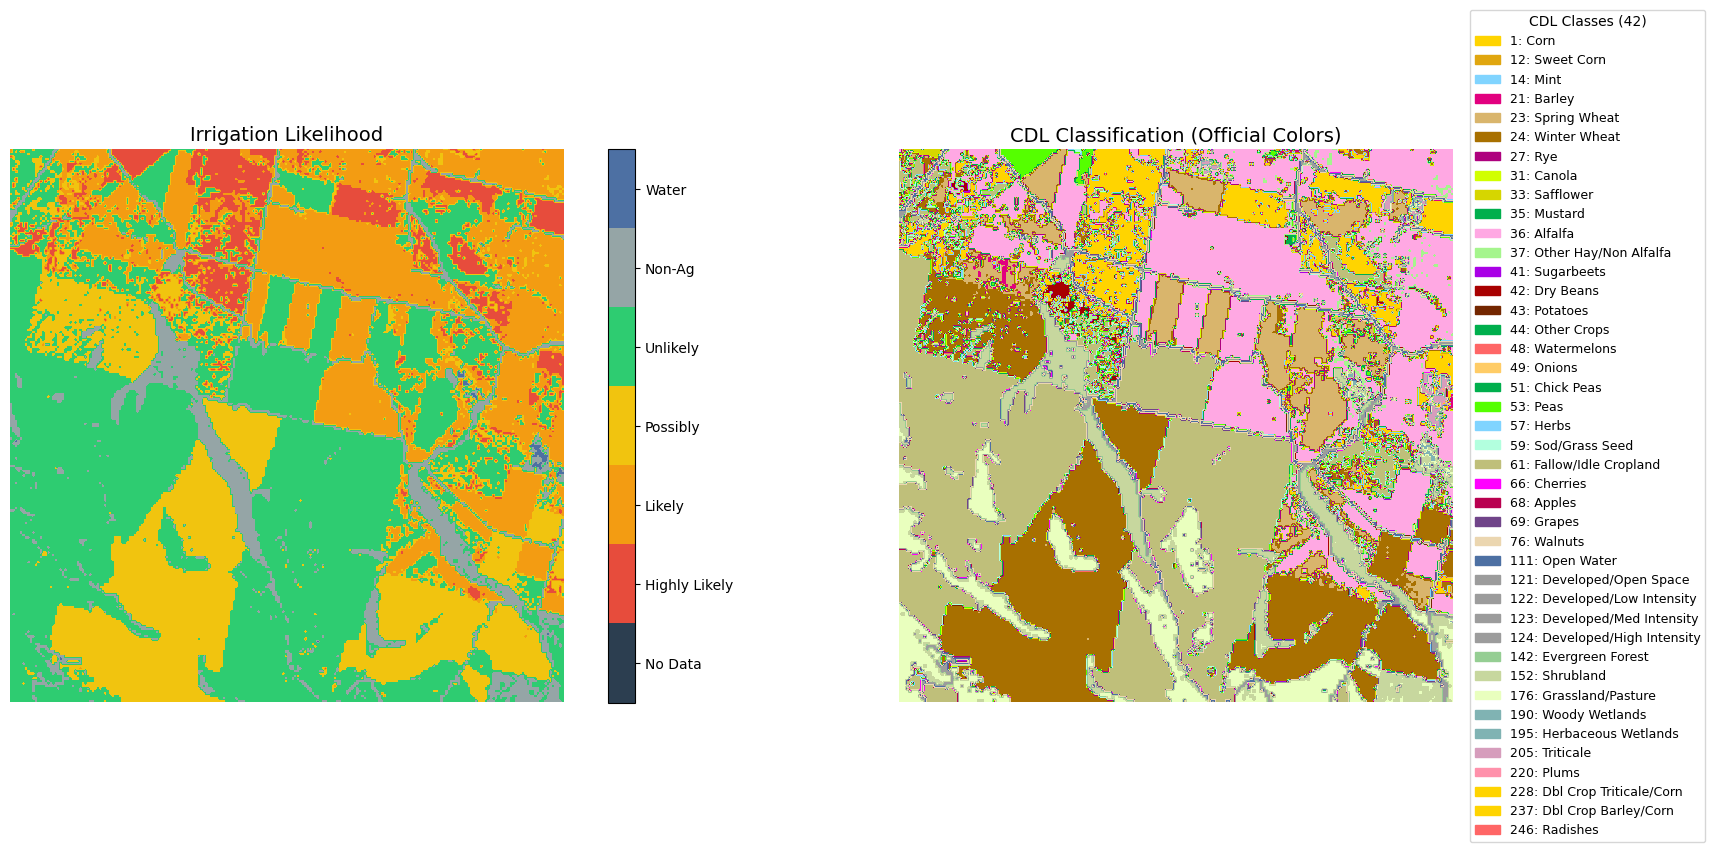

In [7]:
# Build CDL colormap using official colors
cdl_colors_list = []
cdl_labels_list = []
for code in sorted(unique_classes):
    cdl_colors_list.append(cdl_color_map.get(code, '#808080'))  # Gray for unmapped
    cdl_labels_list.append(f"{code}: {cdl_name_map.get(code, 'Unknown')}")

# Create discrete colormap for sparse CDL values
cdl_cmap = ListedColormap(cdl_colors_list)
cdl_norm = BoundaryNorm(
    boundaries=np.append(unique_classes - 0.5, unique_classes[-1] + 0.5),
    ncolors=len(unique_classes)
)

# Plot
fig, axes = plt.subplots(ncols=2, figsize=(20, 8))

# Left: Irrigation likelihood
im1 = axes[0].imshow(irrigation_likelihood.values.squeeze(), 
                     cmap=irrigation_cmap, vmin=-0.5, vmax=6.5)
cbar1 = plt.colorbar(im1, ax=axes[0], ticks=np.arange(7))
cbar1.ax.set_yticklabels(irrigation_labels)
axes[0].set_title('Irrigation Likelihood', fontsize=14)
axes[0].axis('off')

# Right: CDL with official colors
im2 = axes[1].imshow(cdl_data, cmap=cdl_cmap, norm=cdl_norm)
legend_patches = [mpatches.Patch(color=cdl_colors_list[i], label=cdl_labels_list[i]) 
                  for i in range(len(unique_classes))]
axes[1].legend(handles=legend_patches, loc='center left', bbox_to_anchor=(1.02, 0.5),
              fontsize=9, title=f'CDL Classes ({len(unique_classes)})')
axes[1].set_title('CDL Classification (Official Colors)', fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()

# Check for unmapped codes in irrigation likelihood
irrigation_data = irrigation_likelihood.values.squeeze()
# print(f"\nIrrigation classes present: {np.unique(irrigation_data[~np.isnan(irrigation_data)])}")

# Identify unmapped CDL codes
unmapped = [c for c in unique_classes if c not in irrigation_likelihood_map]
if unmapped:
    print(f"⚠️  Unmapped CDL codes (defaulted to class 3): {unmapped}")

In [8]:
# 1. Remove tiny patches
from rasterio.features import sieve
irrigation_likelihood = sieve(irrigation_likelihood.astype('int16'), size=4)

In [9]:
# # Lines 171-176: Add after base classification

# # Mode filter (best for categorical irrigation data)
# from scipy.ndimage import generic_filter
# from scipy.stats import mode

# def majority_vote(values):
#     return mode(values, keepdims=False)[0]

# irrigation_likelihood = generic_filter(
#     irrigation_likelihood, majority_vote, size=2, mode='nearest'
# )


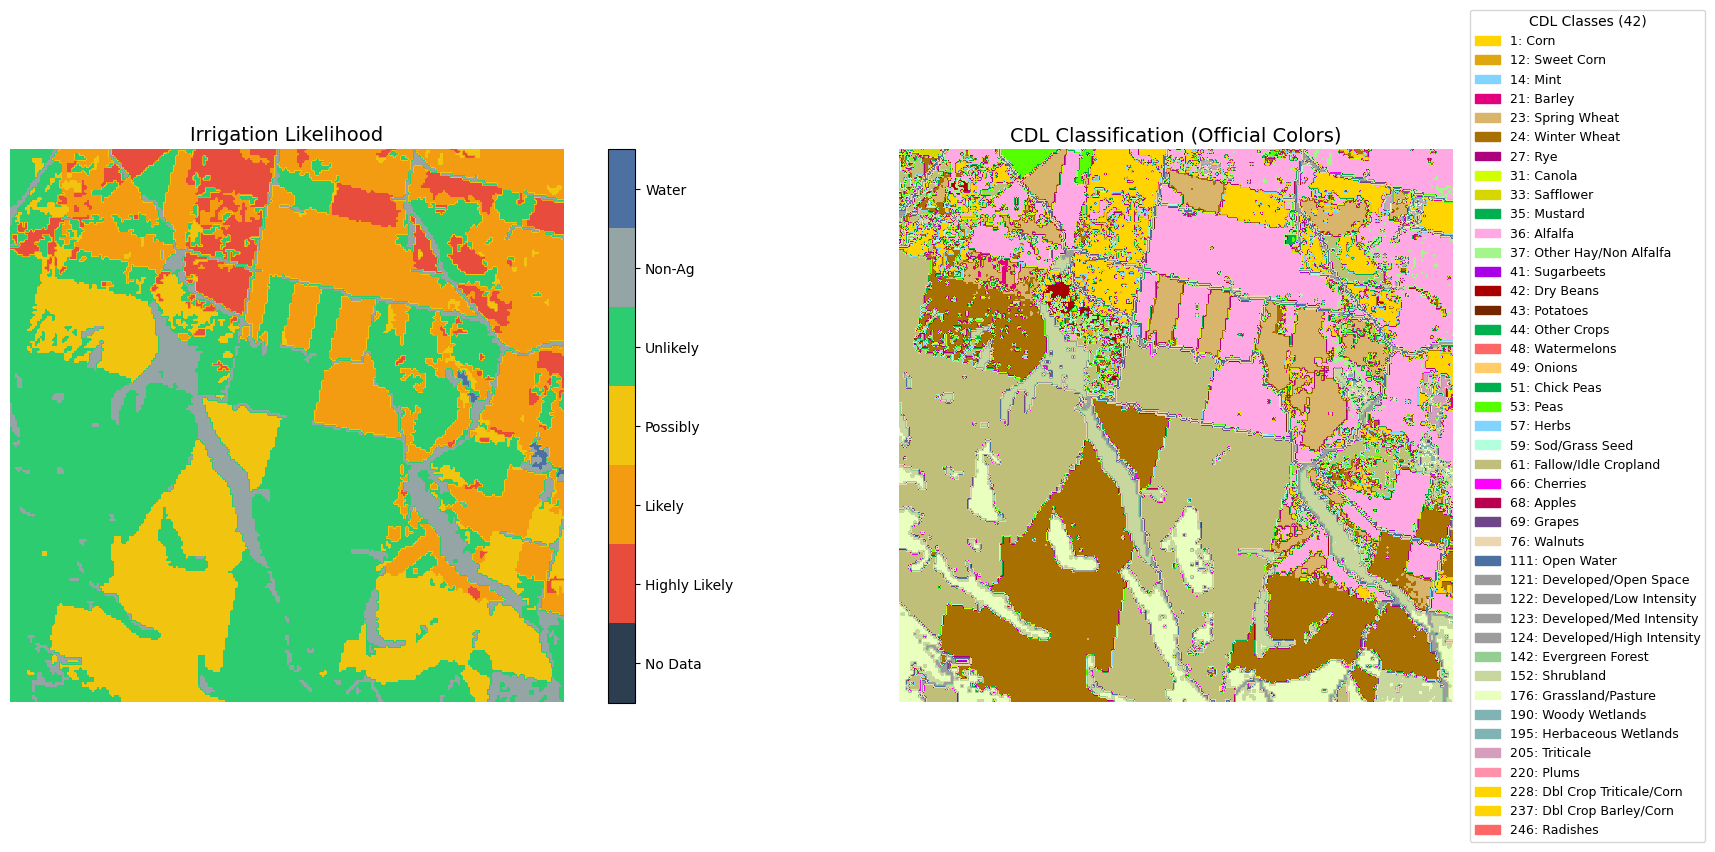

In [10]:
# Build CDL colormap using official colors
cdl_colors_list = []
cdl_labels_list = []
for code in sorted(unique_classes):
    cdl_colors_list.append(cdl_color_map.get(code, '#808080'))  # Gray for unmapped
    cdl_labels_list.append(f"{code}: {cdl_name_map.get(code, 'Unknown')}")

# Create discrete colormap for sparse CDL values
cdl_cmap = ListedColormap(cdl_colors_list)
cdl_norm = BoundaryNorm(
    boundaries=np.append(unique_classes - 0.5, unique_classes[-1] + 0.5),
    ncolors=len(unique_classes)
)

# Plot
fig, axes = plt.subplots(ncols=2, figsize=(20, 8))

# Left: Irrigation likelihood
im1 = axes[0].imshow(irrigation_likelihood.squeeze(), 
                     cmap=irrigation_cmap, vmin=-0.5, vmax=6.5)
cbar1 = plt.colorbar(im1, ax=axes[0], ticks=np.arange(7))
cbar1.ax.set_yticklabels(irrigation_labels)
axes[0].set_title('Irrigation Likelihood', fontsize=14)
axes[0].axis('off')

# Right: CDL with official colors
im2 = axes[1].imshow(cdl_data, cmap=cdl_cmap, norm=cdl_norm)
legend_patches = [mpatches.Patch(color=cdl_colors_list[i], label=cdl_labels_list[i]) 
                  for i in range(len(unique_classes))]
axes[1].legend(handles=legend_patches, loc='center left', bbox_to_anchor=(1.02, 0.5),
              fontsize=9, title=f'CDL Classes ({len(unique_classes)})')
axes[1].set_title('CDL Classification (Official Colors)', fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()

# Check for unmapped codes in irrigation likelihood
irrigation_data = irrigation_likelihood.squeeze()
# print(f"\nIrrigation classes present: {np.unique(irrigation_data[~np.isnan(irrigation_data)])}")

# Identify unmapped CDL codes
unmapped = [c for c in unique_classes if c not in irrigation_likelihood_map]
if unmapped:
    print(f"⚠️  Unmapped CDL codes (defaulted to class 3): {unmapped}")

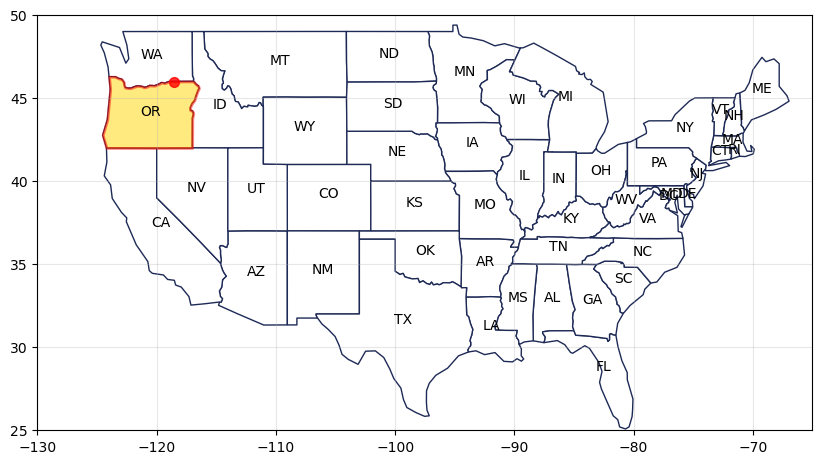

In [11]:
import geopandas as gpd
from shapely.geometry import Point

# Plot coastlines
state_dir = '/discover/nobackup/ejalilva/data/coastline'
state_shp = os.path.join(state_dir, 'ne_110m_admin_1_states_provinces.shp')
state = gpd.read_file(state_shp)
state['iso_3166_2'] = state['iso_3166_2'].str.replace('US-', '', regex=False)

src = rasterio.open(cdl_output_path)    # Use transform_bounds instead of transform to avoid PROJ error
bounds_4326 = transform_bounds(src.crs, 'EPSG:4326', *src.bounds)
center_lon = (bounds_4326[0] + bounds_4326[2]) / 2
center_lat = (bounds_4326[1] + bounds_4326[3]) / 2

# Plot with coastlines
fig, ax = plt.subplots(figsize=(10, 8))

# Find intersecting state
point = Point(center_lon, center_lat)
intersecting_state = state[state.contains(point)]
intersecting_state

# Lines: state.plot(ax=ax, ...) - replace with:
state.plot(ax=ax, color='w', edgecolor='#1E2A56', linewidth=1)
if not intersecting_state.empty:
    intersecting_state.plot(ax=ax, color='#FFD700', edgecolor='red', linewidth=2, alpha=0.5)
state.apply(lambda x: ax.annotate(text=x['iso_3166_2'], xy=x.geometry.centroid.coords[0], ha='center'), axis=1)

# Plot chip centers
ax.scatter(center_lon, center_lat, c='red', s=50, alpha=0.8, zorder=5)

ax.set_xlim(-130, -65)
ax.set_ylim(25, 50)
# ax.set_title(f'{len(chip_files)} Training Chip Locations')
ax.grid(True, alpha=0.3)